## Preparing the data (Cleaning + Preprocessing)

In [37]:
import pandas as pd

path = "data/Latest - Quarterly median rents by Local Government Area - March quarter 2025 (1).xlsx" 

In [39]:


# Reading the column names
rental_data_preview = pd.read_excel(path, header=None)
print(rental_data_preview.head(5))
 


                                               0            1         2    \
0  Quarterly median rents by Local Government Area          NaN       NaN   
1                                  1 bedroom flats          NaN  Jun 1999   
2                                              NaN          NaN     Count   
3                                Barwon South West  Colac-Otway         6   
4                                              NaN  Corangamite         -   

        3         4         5         6         7         8         9    ...  \
0       NaN       NaN       NaN       NaN       NaN       NaN       NaN  ...   
1  Jun 1999  Sep 1999  Sep 1999  Dec 1999  Dec 1999  Mar 2000  Mar 2000  ...   
2    Median     Count    Median     Count    Median     Count    Median  ...   
3        68         6        75         7        80         6        78  ...   
4         -         5        60         -         -         -         -  ...   

        200       201       202       203       204     

In [41]:
# Read in the data again, skipping first three rows
rents = pd.read_excel(path, header=None, skiprows=3)

# Rename first two columns
rents = rents.rename(columns={0: 'Region', 1: 'Sub-Region'})

# Fill down Region names
rents['Region'] = rents['Region'].fillna(method='ffill')

# Get the median rental prices
median_rents = rents.columns[3::2]

# Getting the dates for the median rental prices
rents_header = pd.read_excel(path, header=None, nrows=3)  
date_row = rents_header.iloc[1, 2:]  
date_cols = [str(d) for d in date_row[::2]]  

# Assign previously defined column names
rent_medians = rents[['Region','Sub-Region'] + list(median_cols)]
rent_medians.columns = ['Region','Sub-Region'] + date_cols

# Convert to long format
rents_long = rent_medians.melt(id_vars=['Region','Sub-Region'], var_name='Date', value_name='Median_Rent')

# Convert to datetime format
rents_long['Date'] = pd.to_datetime(rents_long['Date'], format='%b %Y', errors='coerce')

# Convert Median_Rent to numeric type
rents_long['Median_Rent'] = pd.to_numeric(rents_long['Median_Rent'], errors='coerce')

# Sort the entries
rents_long = rents_long.sort_values(['Region','Sub-Region','Date']).reset_index(drop=True)

# Forward-filling sub-region names
rents_long['Sub-Region'] = rents_long['Sub-Region'].fillna(method='ffill')

# Fill missing values for median rent
rents_long['Median_Rent'] = rents_long.groupby('Sub-Region')['Median_Rent'].ffill().bfill()

/var/folders/nw/bpz5p04d2r1cd2372l60hmyc0000gn/T/ipykernel_7039/2156924677.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rents['Region'] = rents['Region'].fillna(method='ffill')


NameError: name 'median_cols' is not defined

In [43]:
print(rents_long.isna().sum())


Region         0
Sub-Region     0
Date           0
Median_Rent    0
dtype: int64


In [45]:
rents_long

,Region,Sub-Region,Date,Median_Rent
0,Barwon South West,Colac-Otway,1999-06-01,68.0
1,Barwon South West,Colac-Otway,1999-09-01,75.0
2,Barwon South West,Colac-Otway,1999-12-01,80.0
3,Barwon South West,Colac-Otway,2000-03-01,78.0
4,Barwon South West,Colac-Otway,2000-06-01,75.0
...,...,...,...,...
9563,Table Total,Victoria,2024-03-01,500.0
9564,Table Total,Victoria,2024-06-01,500.0
9565,Table Total,Victoria,2024-09-01,500.0
9566,Table Total,Victoria,2024-12-01,500.0


## Visualisation

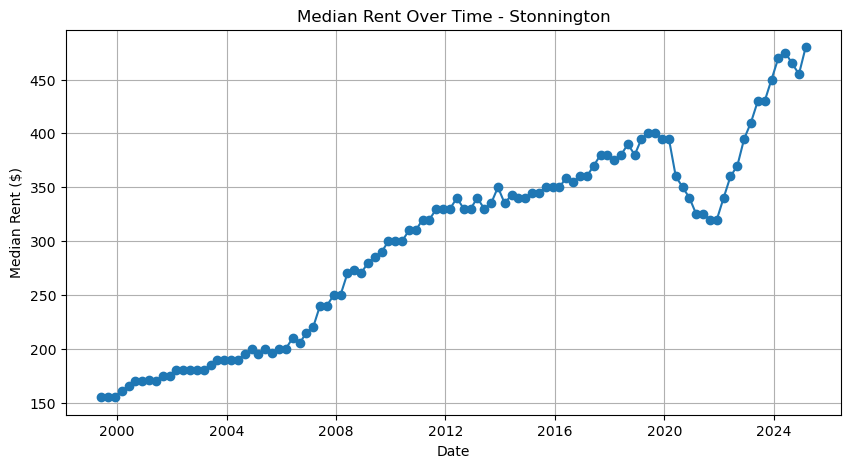

In [47]:
import matplotlib.pyplot as plt

lga = 'Stonnington'
rents_plot = rents_long[rents_long['Sub-Region'] == lga]

plt.figure(figsize=(10,5))
plt.plot(rents_plot['Date'], rents_plot['Median_Rent'], marker='o', linestyle='-')
plt.title(f'Median Rent Over Time - {lga}')
plt.xlabel('Date')
plt.ylabel('Median Rent ($)')
plt.grid(True)
plt.show()


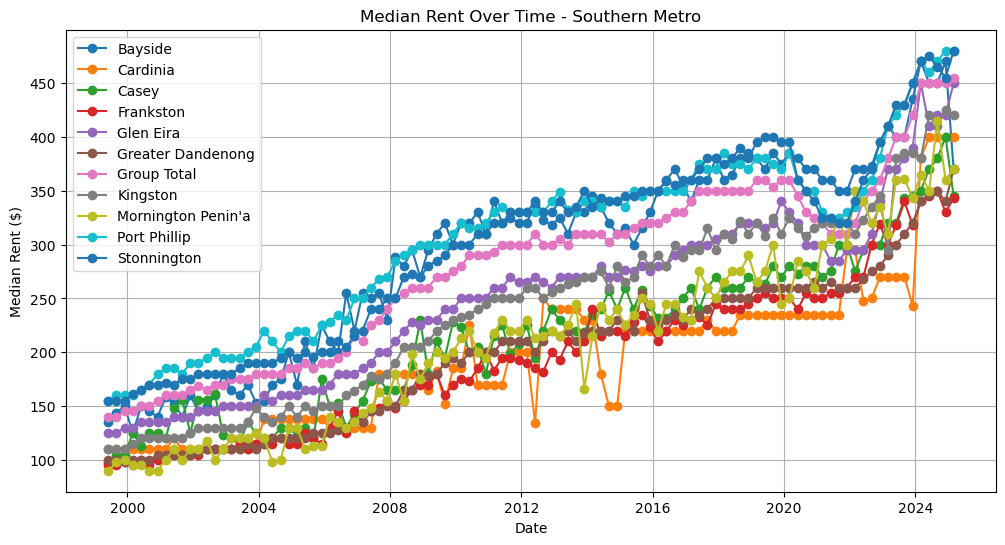

In [49]:
region = 'Southern Metro'
rents_region = rents_long[rents_long['Region'] == region]

plt.figure(figsize=(12,6))
for lga in rents_region['Sub-Region'].unique():
    rents_lga = rents_region[rents_region['Sub-Region'] == lga]
    plt.plot(rents_lga['Date'], rents_lga['Median_Rent'], marker='o', linestyle='-', label=lga)

plt.title(f'Median Rent Over Time - {region}')
plt.xlabel('Date')
plt.ylabel('Median Rent ($)')
plt.legend()
plt.grid(True)
plt.show()


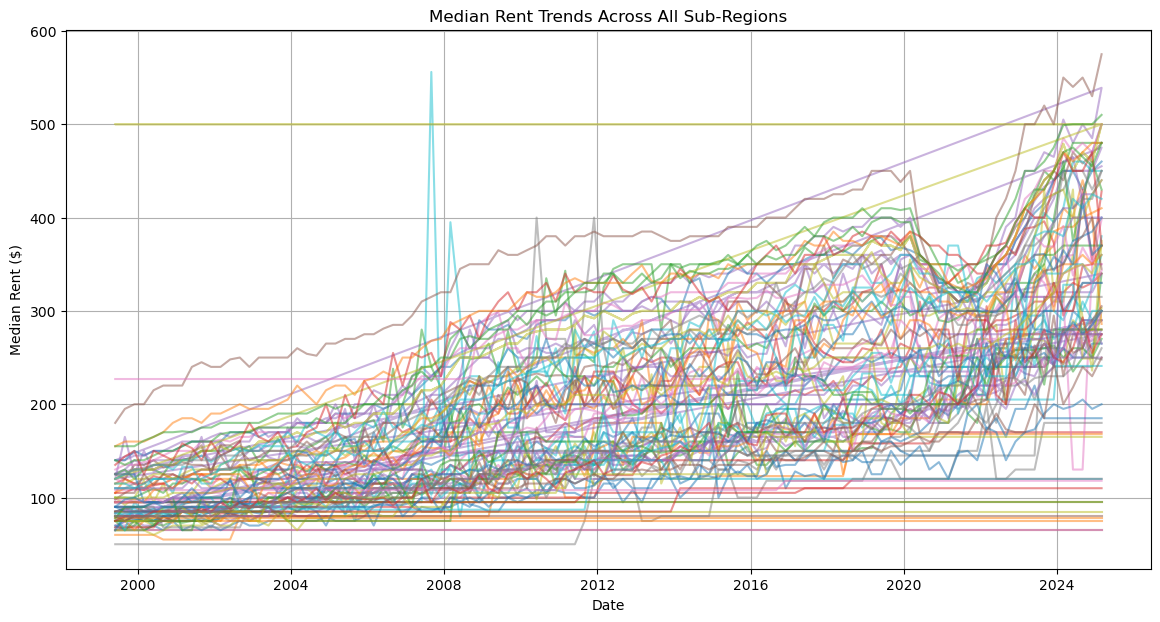

In [51]:
plt.figure(figsize=(14,7))
for lga in rents_long['Sub-Region'].unique():
    rents_lga = rents_long[rents_long['Sub-Region'] == lga]
    plt.plot(rents_lga['Date'], rents_lga['Median_Rent'], alpha=0.5)

plt.title('Median Rent Trends Across All Sub-Regions')
plt.xlabel('Date')
plt.ylabel('Median Rent ($)')
plt.grid(True)
plt.show()

In [26]:
rents_long

,Region,Sub-Region,Date,Median_Rent
0,Barwon South West,Colac-Otway,1999-06-01,68.0
1,Barwon South West,Colac-Otway,1999-09-01,75.0
2,Barwon South West,Colac-Otway,1999-12-01,80.0
3,Barwon South West,Colac-Otway,2000-03-01,78.0
4,Barwon South West,Colac-Otway,2000-06-01,75.0
...,...,...,...,...
9563,Table Total,Victoria,2024-03-01,500.0
9564,Table Total,Victoria,2024-06-01,500.0
9565,Table Total,Victoria,2024-09-01,500.0
9566,Table Total,Victoria,2024-12-01,500.0


## Decomposition

In [28]:
for lga in rents_long['Sub-Region'].unique():
    region = rents_long[rents_long['Sub-Region'] == lga]['Region'].iloc[0]

    timeseries = rents_long[(rents_long['Region'] == region) & (rents_long['Sub-Region'] == lga)]
    timeseries = timeseries.set_index('Date')['Median_Rent'].sort_index()
    
    decomposition = seasonal_decompose(timeseries.dropna(), model='additive', period=4)
    
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.suptitle(f"Time Series Decomposition - {lga} ({region})", fontsize=16)
    plt.show()

NameError: name 'seasonal_decompose' is not defined

In [30]:
for lga in rents_long['Sub-Region'].unique():
    region = rents_long[rents_long['Sub-Region'] == lga]['Region'].iloc[0]

    timeseries = rents_long[(rents_long['Region'] == region) & (rents_long['Sub-Region'] == lga)]
    timeseries = timeseries.set_index('Date')['Median_Rent'].sort_index()
    
    decomposition = seasonal_decompose(timeseries.dropna(), model='multiplicative', period=4)
    
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.suptitle(f"Time Series Decomposition - {lga} ({region})", fontsize=16)
    plt.show()

NameError: name 'seasonal_decompose' is not defined